In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Monza"
away= "Como"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Monza,Roma,2025-02-24,L,A,0,4,-4,0,0,...,0.3,0.3,-0.3,-0.3,-0.3,0.06,1,1.4,0.23,-2.6
26,Monza,Torino,2025-03-02,L,H,0,2,-2,0,0,...,0.9,0.7,-1.0,-1.0,-0.9,0.12,0,1.7,0.24,-0.3
27,Monza,Inter,2025-03-08,L,A,2,3,-1,2,0,...,0.6,0.2,1.4,1.4,1.4,0.08,0,2.9,0.32,0.9
28,Monza,Parma,2025-03-15,D,H,1,1,0,1,0,...,0.6,0.7,0.3,0.3,0.4,0.06,1,1.6,0.26,0.6
29,Monza,Cagliari,2025-03-30,L,A,0,3,-3,0,0,...,0.3,0.8,-0.4,-0.4,-0.3,0.04,1,1.4,0.35,-1.6


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Roma,Monza,2025-02-24,W,H,4,0,4,4,0,...,1.4,1.0,2.5,2.5,2.6,0.06,0,0.8,0.40,0.8
26,Torino,Monza,2025-03-02,W,A,2,0,2,2,0,...,0.9,1.4,0.8,0.8,0.1,0.09,0,0.1,0.07,0.1
27,Inter,Monza,2025-03-08,W,H,3,2,1,2,0,...,2.5,3.8,-0.6,-0.6,-0.5,0.09,0,1.3,0.32,-0.7
28,Parma,Monza,2025-03-15,D,A,1,1,0,1,0,...,0.4,0.6,0.3,0.3,0.6,0.05,0,1.0,0.25,0.0
29,Cagliari,Monza,2025-03-30,W,H,3,0,3,3,0,...,1.4,0.8,1.3,1.3,0.6,0.18,1,0.4,0.13,0.4


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Como,Napoli,2025-02-23,W,H,2,1,1,1,0,...,0.6,0.5,0.3,0.3,0.4,0.09,0,0.6,0.16,-0.4
26,Como,Roma,2025-03-02,L,A,1,2,-1,1,0,...,0.9,0.5,-0.2,-0.2,0.1,0.12,0,1.5,0.39,-0.5
27,Como,Venezia,2025-03-08,D,H,1,1,0,1,0,...,0.3,0.7,-0.3,-0.3,-0.3,0.12,0,1.4,0.11,0.4
28,Como,Milan,2025-03-15,L,A,1,2,-1,1,0,...,0.9,0.6,0.0,0.0,0.1,0.07,1,1.0,0.33,-1.0
29,Como,Empoli,2025-03-29,D,H,1,1,0,1,0,...,1.8,1.0,-0.9,-0.9,-0.8,0.12,0,1.2,0.29,0.2


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Napoli,Como,2025-02-23,L,A,1,2,-1,1,0,...,0.8,0.5,-0.2,-0.2,-0.8,0.10,1,1.4,0.47,0.4
26,Roma,Como,2025-03-02,W,H,2,1,1,2,0,...,1.6,1.3,0.4,0.4,0.4,0.14,0,1.2,0.40,0.2
27,Venezia,Como,2025-03-08,D,A,1,1,0,0,1,...,0.5,0.3,-0.3,-0.5,-0.5,0.06,0,2.6,0.39,1.6
28,Milan,Como,2025-03-15,W,H,2,1,1,2,0,...,1.3,0.6,0.7,0.7,0.7,0.14,0,1.2,0.20,0.2
29,Empoli,Como,2025-03-29,D,A,1,1,0,1,0,...,1.8,1.3,-1.0,-1.0,-0.8,0.14,1,1.9,0.39,0.9


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'G-PK', 'PK', 'PKatt', 'PKm', 'Poss', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,0,0,0,35,0,17,5,29.4,9,52.9,...,-1.2,-1.2,0.3,0.3,-0.3,-0.3,-0.3,0.06,1,0
26,0,0,0,53,0,5,4,80.0,0,0.0,...,-0.1,-0.1,0.9,0.7,-1.0,-1.0,-0.9,0.12,0,0
27,2,0,0,31,0,15,6,40.0,7,46.7,...,-1.9,-1.9,0.6,0.2,1.4,1.4,1.4,0.08,0,2
28,1,0,0,45,0,11,7,63.6,4,36.4,...,0.0,0.0,0.6,0.7,0.3,0.3,0.4,0.06,1,1
29,0,0,0,58,0,14,5,35.7,8,57.1,...,-1.3,-1.3,0.3,0.8,-0.4,-0.4,-0.3,0.04,1,0


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,4,0,0,65,0,18,7,38.9,11,61.1,...,1.2,1.2,1.4,1.0,2.5,2.5,2.6,0.06,0,4
26,2,0,0,47,0,10,4,40.0,5,50.0,...,0.1,0.1,0.9,1.4,0.8,0.8,0.1,0.09,0,2
27,2,0,0,69,0,7,4,57.1,3,42.9,...,1.9,1.9,2.5,3.8,-0.6,-0.6,-0.5,0.09,0,3
28,1,0,0,55,0,20,10,50.0,9,45.0,...,0.0,0.0,0.4,0.6,0.3,0.3,0.6,0.05,0,1
29,3,0,0,42,0,26,9,34.6,15,57.7,...,1.3,1.3,1.4,0.8,1.3,1.3,0.6,0.18,1,3


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,1,0,0,42,0,22,8,36.4,9,40.9,...,-0.5,-0.5,0.6,0.5,0.3,0.3,0.4,0.09,0,2
26,1,0,0,52,0,18,10,55.6,8,44.4,...,-0.4,-0.4,0.9,0.5,-0.2,-0.2,0.1,0.12,0,1
27,1,0,0,55,0,14,7,50.0,7,50.0,...,0.0,0.8,0.3,0.7,-0.3,-0.3,-0.3,0.12,0,1
28,1,0,0,58,0,18,5,27.8,10,55.6,...,-0.3,-0.3,0.9,0.6,0.0,0.0,0.1,0.07,1,1
29,1,0,0,71,0,19,5,26.3,7,36.8,...,-0.1,-0.1,1.8,1.0,-0.9,-0.9,-0.8,0.12,0,1


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,1,0,0,58,0,25,9,36.0,12,48.0,...,0.5,0.5,0.8,0.5,-0.2,-0.2,-0.8,0.10,1,1
26,2,0,0,48,0,18,8,44.4,8,44.4,...,0.4,0.4,1.6,1.3,0.4,0.4,0.4,0.14,0,2
27,0,1,0,45,1,22,9,40.9,12,54.5,...,0.0,-0.8,0.5,0.3,-0.3,-0.5,-0.5,0.06,0,1
28,2,0,0,42,0,18,8,44.4,9,50.0,...,0.3,0.3,1.3,0.6,0.7,0.7,0.7,0.14,0,2
29,1,0,0,29,0,10,9,90.0,1,10.0,...,0.1,0.1,1.8,1.3,-1.0,-1.0,-0.8,0.14,1,1


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
25,14,3,21.4,0,0,5.0,0,NaN,0,1,...,8,6,6,23,26,1,1.4,0.23,-2.6,4
26,16,0,0.0,0,0,NaN,0,NaN,0,0,...,1,5,5,12,24,1,1.7,0.24,-0.3,2
27,31,1,3.2,0,1,9.0,0,NaN,0,0,...,9,3,8,20,39,0,2.9,0.32,0.9,3
28,13,1,7.7,0,0,4.3,0,NaN,0,0,...,3,8,6,27,24,1,1.6,0.26,0.6,1
29,13,0,0.0,0,0,10.8,0,NaN,1,0,...,4,10,10,30,18,1,1.4,0.35,-1.6,3


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
25,6,1,16.7,0,0,9.7,0,NaN,0,0,...,1,0,8,26,5,0,0.8,0.40,0.8,0
26,18,1,5.6,0,4,19.3,0,NaN,0,0,...,3,11,12,20,15,0,0.1,0.07,0.1,0
27,3,0,0.0,0,0,NaN,0,NaN,0,0,...,2,3,4,20,9,0,1.3,0.32,-0.7,2
28,15,0,0.0,0,2,26.3,0,NaN,0,1,...,2,6,4,17,18,0,1.0,0.25,0.0,1
29,19,1,5.3,0,5,20.5,0,NaN,0,0,...,5,7,8,24,30,0,0.4,0.13,0.4,0


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,9,0,0.0,0,2,16.0,0,NaN,0,0,...,1,3,4,11,10,2,2.3,0.38,-0.7,3
1,18,1,5.6,0,0,12.0,0,NaN,0,0,...,2,11,9,21,34,0,1.4,0.28,0.4,1
2,11,0,0.0,0,0,18.0,0,NaN,0,0,...,3,7,11,37,21,0,0.6,0.31,-0.4,1
3,12,1,8.3,0,0,1.0,0,NaN,0,0,...,5,11,8,31,21,0,1.3,0.33,-0.7,2
4,26,2,7.7,1,0,7.7,0,0.0,0,1,...,0,6,13,42,32,0,1.5,0.17,-0.5,2


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,10,1,10.0,0,0,4.0,0,NaN,0,0,...,2,8,4,19,10,0,0.0,NaN,0.0,0
1,17,0,0.0,0,2,15.4,0,NaN,0,1,...,6,4,3,17,32,1,1.1,0.27,0.1,1
2,17,0,0.0,1,0,8.5,0,NaN,0,0,...,6,16,11,33,27,1,0.3,0.08,0.3,0
3,9,0,0.0,0,2,15.5,0,NaN,0,0,...,4,6,5,26,9,1,1.0,0.24,0.0,2
4,6,1,16.7,0,2,16.8,0,NaN,0,0,...,3,10,6,20,9,0,2.2,0.33,0.2,3


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,9,7,56.3,1,0,0,7,6,31
26,14,7,66.7,2,0,0,10,20,27
27,8,26,23.5,1,0,0,7,5,21
28,8,8,50.0,0,0,0,14,14,23
29,10,28,26.3,2,0,0,11,16,37


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,7,9,43.8,0,0,0,6,7,52
26,7,14,33.3,2,0,0,20,8,35
27,26,8,76.5,0,0,0,8,6,39
28,8,8,50.0,3,0,0,16,14,31
29,28,10,73.7,2,0,0,17,9,45


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,17,13,56.7,1,0,0,17,14,45
26,14,11,56.0,7,1,1,18,5,45
27,6,11,35.3,2,0,0,11,12,41
28,8,9,47.1,3,1,0,7,21,43
29,13,23,36.1,2,0,0,5,21,28


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,13,17,43.3,3,0,0,14,17,40
26,11,14,44.0,2,0,0,6,17,48
27,11,6,64.7,3,0,0,14,11,42
28,9,8,52.9,3,0,0,21,7,40
29,23,13,63.9,5,1,0,22,5,36


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,0,0,0,35,0,17,5,29.4,9,52.9,...,-0.275,0.150000,-0.225,0.125831,0.0525,0.026300,0.75,0.50000,0.25,0.500000
26,0,0,0,53,0,5,4,80.0,0,0.0,...,-0.250,0.129099,-0.200,0.081650,0.0450,0.012910,1.00,0.00000,0.25,0.500000
27,2,0,0,31,0,15,6,40.0,7,46.7,...,-0.400,0.408248,-0.375,0.359398,0.0650,0.038730,0.75,0.50000,0.25,0.500000
28,1,0,0,45,0,11,7,63.6,4,36.4,...,-0.025,1.014479,0.000,0.983192,0.0725,0.037749,0.50,0.57735,0.50,1.000000
29,0,0,0,58,0,14,5,35.7,8,57.1,...,0.100,1.016530,0.150,0.988264,0.0800,0.028284,0.50,0.57735,0.75,0.957427


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,4,0,0,65,0,18,7,38.9,11,61.1,...,0.025,1.273774,0.200,1.256981,0.0900,0.031623,0.75,1.5,2.00,2.160247
26,2,0,0,47,0,10,4,40.0,5,50.0,...,0.625,1.783956,0.750,1.755942,0.0775,0.030957,0.75,1.5,2.50,2.380476
27,2,0,0,69,0,7,4,57.1,3,42.9,...,1.050,1.475353,0.975,1.534872,0.0800,0.031623,0.75,1.5,2.75,2.217356
28,1,0,0,55,0,20,10,50.0,9,45.0,...,0.450,1.554563,0.375,1.521786,0.0725,0.020616,0.75,1.5,2.25,1.707825
29,3,0,0,42,0,26,9,34.6,15,57.7,...,0.750,1.302562,0.700,1.344123,0.0725,0.020616,0.00,0.0,2.50,1.290994


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,14,1,7.1,0,6,17.6,0,0.0,0,0,...,0.25,0.500000,1.275,0.670199,0.3250,0.204695,-0.225,0.386221,1.50,1.000000
26,4,0,0.0,0,3,26.0,0,0.0,0,0,...,0.75,0.957427,1.025,0.694622,0.2300,0.153406,-0.225,0.386221,1.25,0.957427
27,8,3,37.5,1,1,12.3,0,0.0,0,0,...,0.75,0.957427,0.950,0.591608,0.2150,0.125033,-0.300,0.408248,1.25,0.957427
28,1,0,0.0,0,1,22.0,0,0.0,0,0,...,0.75,0.957427,0.950,0.591608,0.1900,0.135892,-0.050,0.465475,1.00,0.816497
29,8,1,12.5,0,12,23.3,0,0.0,0,0,...,0.75,0.957427,1.125,0.411299,0.2475,0.133760,-0.375,0.579511,1.50,0.577350


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,7,0,0.0,0,3,20.5,0,0.0,0,0,...,0.75,0.957427,1.050,0.580230,0.2875,0.078049,0.050,0.732575,1.00,0.816497
26,8,2,25.0,0,1,13.0,0,0.0,0,0,...,1.00,1.154701,1.175,0.590903,0.3575,0.086554,0.175,0.741058,1.25,0.957427
27,11,1,9.1,0,0,9.5,0,0.0,0,0,...,1.00,1.154701,1.375,0.309570,0.3625,0.088835,0.125,0.727438,1.50,0.577350
28,10,1,10.0,0,2,22.0,0,0.0,0,0,...,0.75,0.957427,1.575,0.694622,0.3850,0.078528,0.325,1.024288,1.50,0.577350
29,18,1,5.6,0,0,3.3,0,0.0,0,0,...,0.75,0.957427,1.600,0.673300,0.3650,0.115614,0.600,0.673300,1.25,0.500000


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,1,0,0,42,0,22,8,36.4,9,40.9,...,0.250,0.704746,0.375,0.639661,0.0700,0.021602,0.50,0.57735,1.00,0.816497
26,1,0,0,52,0,18,10,55.6,8,44.4,...,0.275,0.704154,0.350,0.635085,0.0800,0.018257,0.25,0.50000,1.25,0.957427
27,1,0,0,55,0,14,7,50.0,7,50.0,...,0.350,0.602771,0.450,0.519615,0.0925,0.025000,0.00,0.00000,1.50,0.577350
28,1,0,0,58,0,18,5,27.8,10,55.6,...,0.250,0.685565,0.350,0.635085,0.1075,0.015000,0.00,0.00000,1.50,0.577350
29,1,0,0,71,0,19,5,26.3,7,36.8,...,-0.050,0.264575,0.075,0.287228,0.1000,0.024495,0.25,0.50000,1.25,0.500000


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,1,0,0,58,0,25,9,36.0,12,48.0,...,0.450,0.544671,5.250000e-01,0.567891,0.0975,0.066018,0.50,1.000000,1.50,1.000000
26,2,0,0,48,0,18,8,44.4,8,44.4,...,0.150,0.465475,7.500000e-02,0.750000,0.0750,0.028868,0.75,0.957427,1.25,0.957427
27,0,1,0,45,1,22,9,40.9,12,54.5,...,0.125,0.442531,-2.775558e-17,0.678233,0.0850,0.043589,0.25,0.500000,1.25,0.957427
28,2,0,0,42,0,18,8,44.4,9,50.0,...,-0.150,0.387298,-3.000000e-01,0.509902,0.0875,0.041130,0.25,0.500000,1.00,0.816497
29,1,0,0,29,0,10,9,90.0,1,10.0,...,0.100,0.547723,-5.000000e-02,0.714143,0.1100,0.038297,0.25,0.500000,1.50,0.577350


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,14,3,21.4,0,0,5.0,0,0.0,0,1,...,1.00,1.414214,2.200,1.657307,0.3075,0.155000,0.450,0.998332,2.00,2.160247
26,16,0,0.0,0,0,0.0,0,0.0,0,0,...,1.25,1.258306,1.750,1.535144,0.2625,0.140801,-0.500,1.645195,2.50,2.380476
27,31,1,3.2,0,1,9.0,0,0.0,0,0,...,1.25,1.258306,1.925,1.459166,0.2575,0.141274,-0.825,1.352467,2.75,2.217356
28,13,1,7.7,0,0,4.3,0,0.0,0,0,...,1.25,1.258306,1.650,0.953939,0.2250,0.086603,-0.350,1.584298,2.25,1.707825
29,13,0,0.0,0,0,10.8,0,0.0,1,0,...,0.75,0.500000,1.900,0.678233,0.2625,0.040311,-0.350,1.584298,2.50,1.290994


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,6,1,16.7,0,0,9.7,0,0.0,0,0,...,0.25,0.5,0.250,0.331662,0.0400,0.048305,5.551115e-17,0.244949,0.25,0.500000
26,18,1,5.6,0,4,19.3,0,0.0,0,0,...,0.25,0.5,0.450,0.369685,0.1325,0.184639,2.000000e-01,0.469042,0.25,0.500000
27,3,0,0.0,0,0,0.0,0,0.0,0,0,...,0.00,0.0,0.475,0.330404,0.1450,0.175973,2.250000e-01,0.457347,0.25,0.500000
28,15,0,0.0,0,2,26.3,0,0.0,0,1,...,0.00,0.0,0.625,0.537742,0.2250,0.160104,1.250000e-01,0.623832,0.50,1.000000
29,19,1,5.3,0,5,20.5,0,0.0,0,0,...,0.00,0.0,0.800,0.509902,0.2600,0.140712,5.000000e-02,0.613732,0.75,0.957427


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
25,9,7,56.3,1,0,0,7,6,31,17.75,...,0.0,0.0,0.0,0.0,13.25,3.947573,13.50,4.932883,32.75,6.184658
26,14,7,66.7,2,0,0,10,20,27,14.75,...,0.0,0.0,0.0,0.0,10.25,2.362908,11.75,6.238322,33.50,5.567764
27,8,26,23.5,1,0,0,7,5,21,12.00,...,0.0,0.0,0.0,0.0,9.75,2.061553,11.75,6.238322,30.00,3.162278
28,8,8,50.0,0,0,0,14,14,23,12.75,...,0.0,0.0,0.0,0.0,8.50,1.732051,11.00,6.976150,28.25,5.619905
29,10,28,26.3,2,0,0,11,16,37,9.75,...,0.0,0.0,0.0,0.0,9.50,3.316625,11.25,7.088723,25.50,4.434712


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
25,7,9,43.8,0,0,0,6,7,52,22.50,...,0.0,0.0,0.0,0.0,16.00,5.715476,12.50,4.654747,40.00,6.480741
26,7,14,33.3,2,0,0,20,8,35,18.75,...,0.0,0.0,0.0,0.0,14.25,7.675719,9.50,2.380476,44.50,7.141428
27,26,8,76.5,0,0,0,8,6,39,13.25,...,0.0,0.0,0.0,0.0,13.50,6.608076,8.50,1.732051,41.00,7.615773
28,8,8,50.0,3,0,0,16,14,31,16.50,...,0.0,0.0,0.0,0.0,13.00,7.023769,7.25,0.957427,41.50,7.325754
29,28,10,73.7,2,0,0,17,9,45,12.00,...,0.0,0.0,0.0,0.0,12.50,6.608076,8.75,3.593976,39.25,9.105859


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
25,17,13,56.7,1,0,0,17,14,45,11.50,...,0.25,0.50000,0.00,0.0,18.00,4.242641,13.00,2.708013,39.50,8.504901
26,14,11,56.0,7,1,1,18,5,45,13.75,...,0.25,0.50000,0.00,0.0,18.50,3.872983,14.25,0.500000,40.00,8.831761
27,6,11,35.3,2,0,0,11,12,41,15.50,...,0.25,0.50000,0.25,0.5,18.50,3.872983,11.75,4.500000,41.50,9.110434
28,8,9,47.1,3,1,0,7,21,43,12.50,...,0.25,0.50000,0.25,0.5,17.50,5.322906,11.25,4.272002,44.75,2.872281
29,13,23,36.1,2,0,0,5,21,28,11.25,...,0.50,0.57735,0.25,0.5,13.25,5.188127,13.00,6.582806,43.50,1.914854


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
25,13,17,43.3,3,0,0,14,17,40,12.00,...,0.0,0.0,0.0,0.0,13.75,2.629956,17.50,4.509250,43.00,5.099020
26,11,14,44.0,2,0,0,6,17,48,12.00,...,0.0,0.0,0.0,0.0,14.75,0.957427,18.25,3.947573,42.25,5.315073
27,11,6,64.7,3,0,0,14,11,42,13.00,...,0.0,0.0,0.0,0.0,12.25,4.193249,18.25,3.947573,42.25,5.315073
28,9,8,52.9,3,0,0,21,7,40,11.75,...,0.0,0.0,0.0,0.0,12.00,4.000000,17.25,5.315073,41.50,5.000000
29,23,13,63.9,5,1,0,22,5,36,11.00,...,0.0,0.0,0.0,0.0,13.75,6.130525,13.00,4.898979,42.50,3.785939


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,0,0,0,58,0,14,5,35.7,8,57.1,...,0.957427,1.125,0.411299,0.2475,0.13376,-0.375,0.579511,1.5,0.57735,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,0,61,0,11,4,36.4,6,54.5,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,H,0
1,0,0,0,69,0,10,6,60.0,3,30.0,...,0.0,0.0,12.000000,0.000000,11.000000,0.000000,24.000000,0.000000,A,2
2,2,0,0,32,0,14,2,14.3,9,64.3,...,0.0,0.0,11.000000,1.414214,10.500000,0.707107,32.000000,11.313708,H,1
3,1,0,0,40,0,19,11,57.9,5,26.3,...,0.0,0.0,10.333333,1.527525,11.333333,1.527525,37.333333,12.220202,H,1
4,1,0,0,43,0,12,6,50.0,5,41.7,...,0.0,0.0,12.000000,3.559026,11.500000,1.290994,42.250000,14.008926,A,0


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,13,0,0.0,0,0,10.8,0,0.0,1,0,...,0.57735,0.25,0.5,13.25,5.188127,13.0,6.582806,43.5,1.914854,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,13,0,0.0,0,1,10.0,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,H,1
1,15,0,0.0,0,1,19.7,0,0.0,0,0,...,0.0,0.0,12.000000,0.000000,11.000000,0.000000,24.000000,0.000000,A,2
2,22,0,0.0,0,2,28.0,0,0.0,0,2,...,0.0,0.0,11.000000,1.414214,10.500000,0.707107,32.000000,11.313708,H,1
3,21,0,0.0,0,0,5.0,0,0.0,0,0,...,0.0,0.0,10.333333,1.527525,11.333333,1.527525,37.333333,12.220202,H,2
4,11,0,0.0,0,0,0.0,0,0.0,0,0,...,0.0,0.0,12.000000,3.559026,11.500000,1.290994,42.250000,14.008926,A,2


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,1,0,0,71,0,19,5,26.3,7,36.8,...,0.57735,0.25,0.5,13.25,5.188127,13.0,6.582806,43.5,1.914854,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,0,43,0,10,2,20.0,6,60.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,1
1,1,0,0,53,0,12,7,58.3,5,41.7,...,0.0,0.0,12.000000,0.000000,11.000000,0.000000,24.000000,0.000000,A,0
2,0,0,1,56,1,15,11,73.3,4,26.7,...,0.0,0.0,11.000000,1.414214,10.500000,0.707107,32.000000,11.313708,H,2
3,1,0,0,44,0,19,9,47.4,10,52.6,...,0.0,0.0,10.333333,1.527525,11.333333,1.527525,37.333333,12.220202,A,3
4,2,0,0,41,0,9,4,44.4,3,33.3,...,0.0,0.0,12.000000,3.559026,11.500000,1.290994,42.250000,14.008926,H,3


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,8,1,12.5,0,12,23.3,0,0.0,0,0,...,0.57735,0.25,0.5,13.25,5.188127,13.0,6.582806,43.5,1.914854,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,9,0,0.0,0,2,16.0,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,1
1,18,1,5.6,0,0,12.0,0,0.0,0,0,...,0.0,0.0,12.000000,0.000000,11.000000,0.000000,24.000000,0.000000,A,1
2,11,0,0.0,0,0,18.0,0,0.0,0,0,...,0.0,0.0,11.000000,1.414214,10.500000,0.707107,32.000000,11.313708,H,2
3,12,1,8.3,0,0,1.0,0,0.0,0,0,...,0.0,0.0,10.333333,1.527525,11.333333,1.527525,37.333333,12.220202,A,2
4,26,2,7.7,1,0,7.7,0,0.0,0,1,...,0.0,0.0,12.000000,3.559026,11.500000,1.290994,42.250000,14.008926,H,2


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

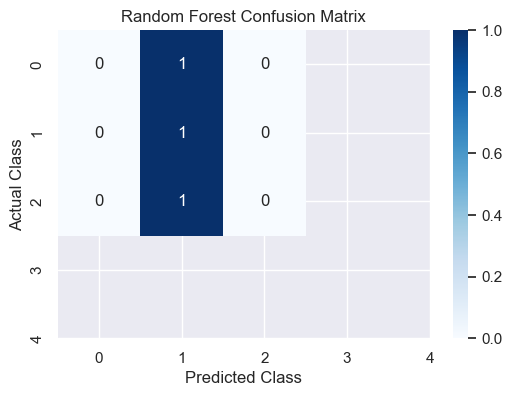

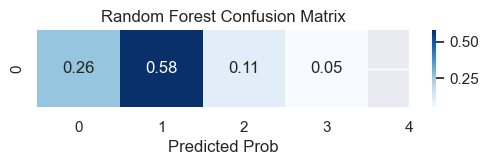

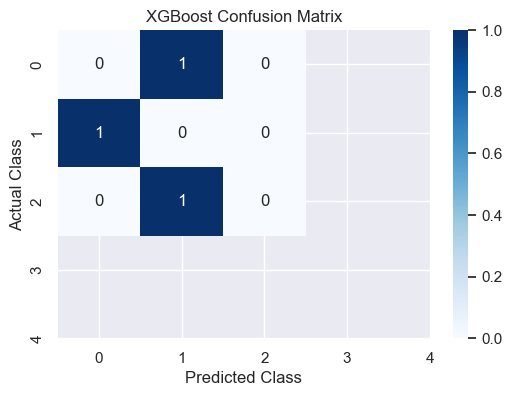

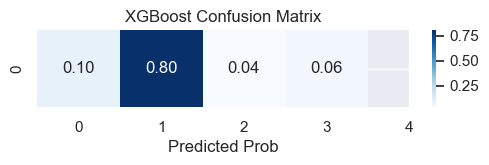

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

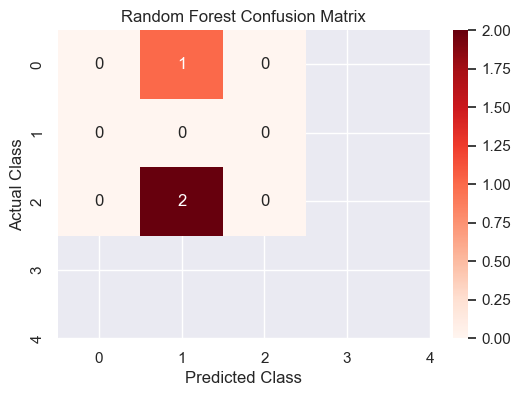

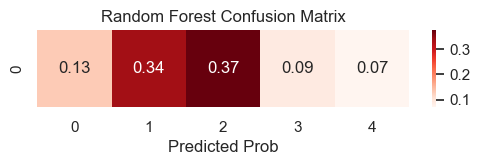

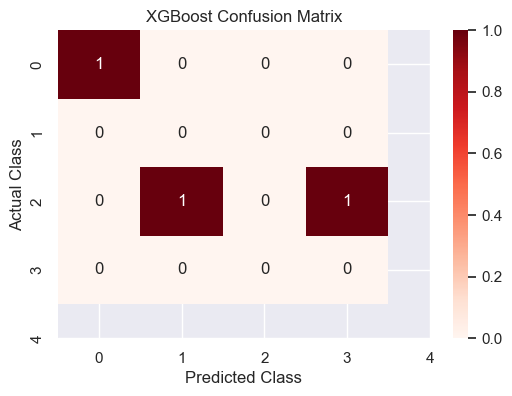

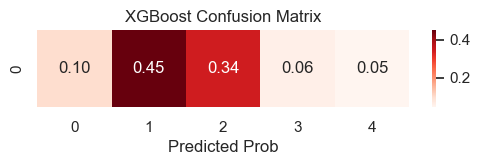

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

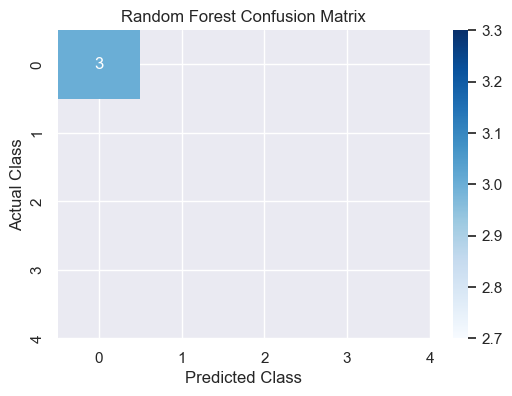

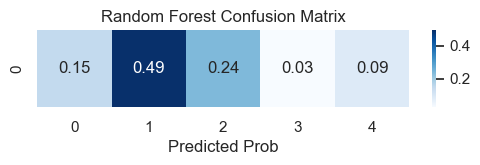

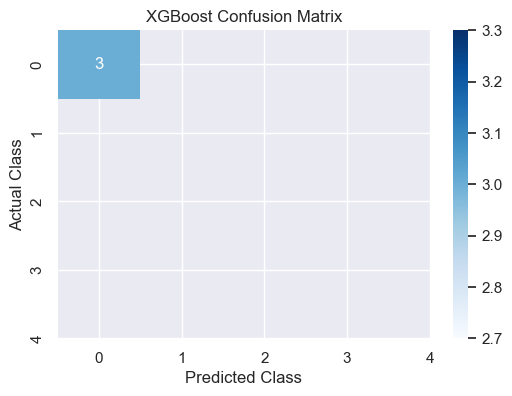

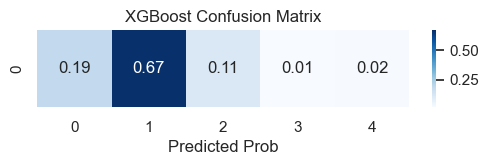

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

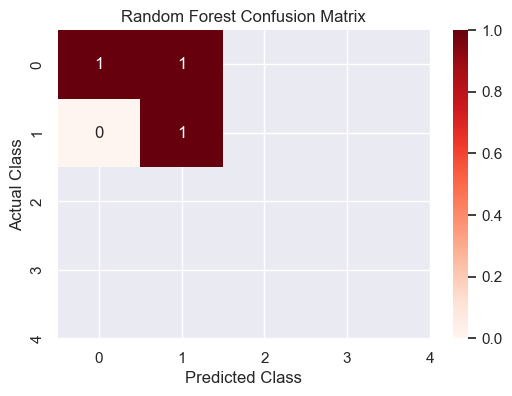

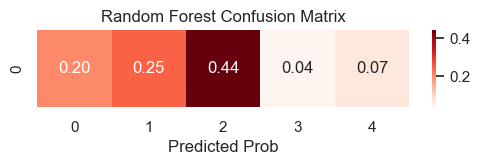

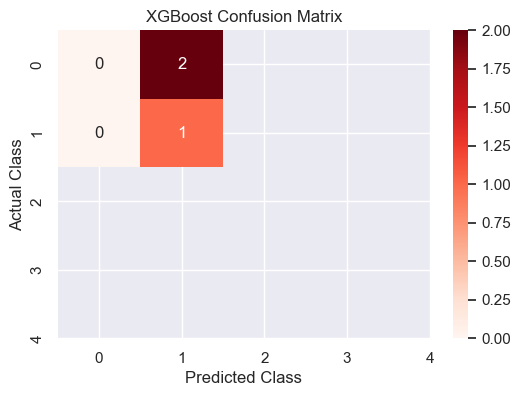

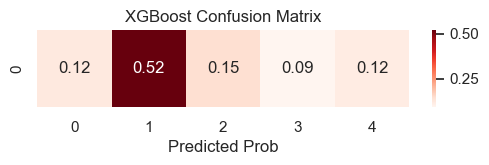

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

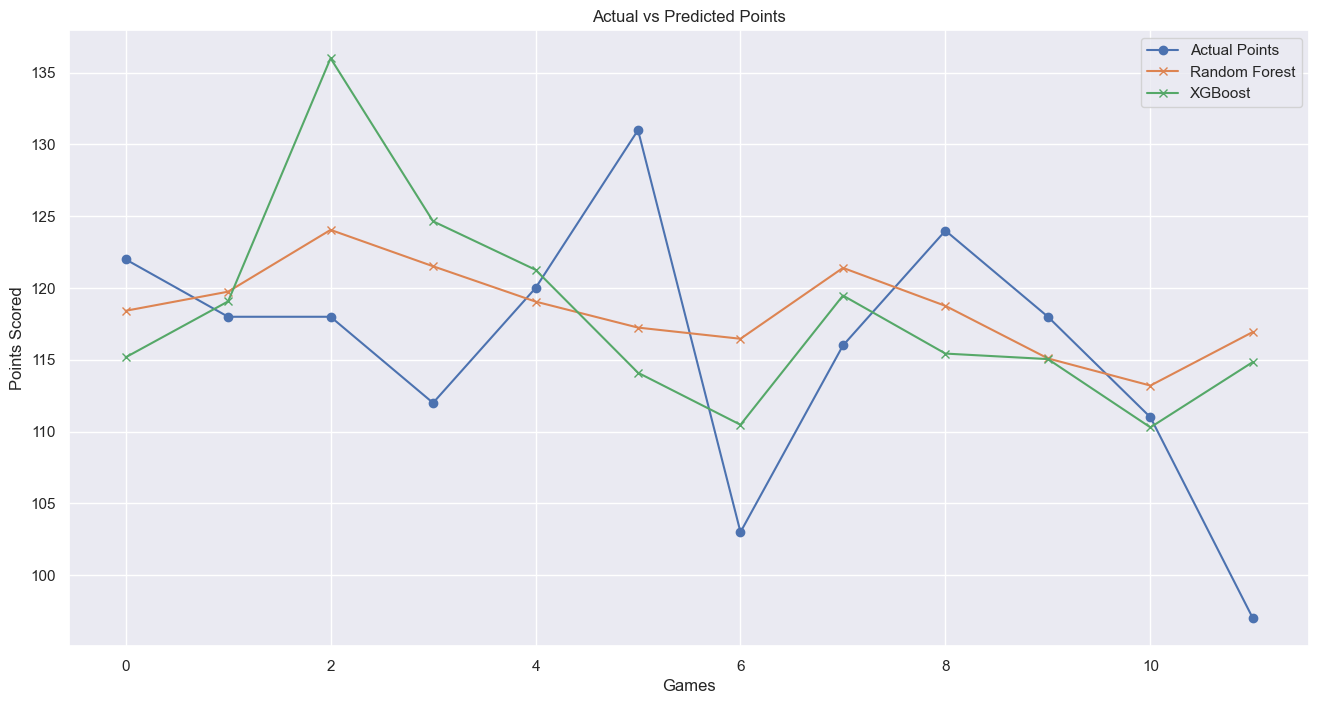

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
